In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0-rc1


In [21]:
df = pd.read_csv("../data/data_macro.csv", parse_dates=["Date"])
df = df.sort_values(["ticker", "Date"]).reset_index(drop=True)

HORIZONS = [3, 5, 10, 30]

FEATURES = [col for col in df.columns if col not in
            ["Date", "ticker", "target_3d", "target_5d",
             "target_10d", "target_30d", "target_90d", "target_365d"]]

print(f"Признаков: {len(FEATURES)}")
print(f"Строк: {len(df)}")

Признаков: 49
Строк: 37603


In [22]:
# LSTM требует данные в формате [samples, timesteps, features]
# Для каждой точки берём окно из последних N дней

WINDOW = 60  # смотрим на последние 20 дней

def create_sequences(df, target_col, window=20):
    X, y = [], []
    
    # Обрабатываем каждую бумагу отдельно
    for ticker in df["ticker"].unique():
        ticker_df = df[df["ticker"] == ticker].copy()
        
        values = ticker_df[FEATURES].values
        labels = ticker_df[target_col].values
        
        for i in range(window, len(ticker_df)):
            X.append(values[i-window:i])  # окно из 20 дней
            y.append(labels[i])           # метка текущего дня
    
    return np.array(X), np.array(y)

print("Функция создания последовательностей готова")

Функция создания последовательностей готова


In [23]:
# Train/Test split по времени
train_df = df[df["Date"] < "2023-01-01"]
test_df  = df[df["Date"] >= "2023-01-01"]

print(f"Train: {len(train_df)} строк")
print(f"Test:  {len(test_df)} строк")

# Нормализация — важно для LSTM!
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])

# Сохраним scaler — понадобится в FastAPI
joblib.dump(scaler, "../model/scaler.pkl")

train_scaled = df_scaled[df_scaled["Date"] < "2023-01-01"]
test_scaled  = df_scaled[df_scaled["Date"] >= "2023-01-01"]

print("Нормализация выполнена")

Train: 25200 строк
Test:  12403 строк
Нормализация выполнена


In [24]:
def build_lstm(input_shape, n_classes=3):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        BatchNormalization(),
        
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        BatchNormalization(),
        
        Dense(32, activation="relu"),
        Dropout(0.1),
        
        Dense(n_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

# Посмотрим на архитектуру
sample_model = build_lstm((WINDOW, len(FEATURES)))
sample_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 60, 64)         │        29,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,139 (168.51 KB)

 Trainable params: 42,947 (167.76 KB)

 Non-trainable params: 192 (768.00 B)

In [25]:
lstm_results = {}

for h in HORIZONS:
    print(f"\n{'='*50}")
    print(f"Обучаю LSTM горизонт {h} дней...")
    
    target = f"target_{h}d"
    
    # Создаём последовательности
    X_train, y_train = create_sequences(train_scaled, target, WINDOW)
    X_test,  y_test  = create_sequences(test_scaled,  target, WINDOW)
    
    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
    
    # Веса классов
    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight_dict = dict(zip(classes, weights))
    print(f"Веса классов: {class_weight_dict}")
    
    # Строим модель
    model = build_lstm((WINDOW, len(FEATURES)))
    
    # Коллбэки
    callbacks = [
        EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),
        ReduceLROnPlateau(patience=5, factor=0.5, monitor="val_loss")
    ]
    
    # Обучаем
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    
    # Оцениваем
    y_pred = np.argmax(model.predict(X_test), axis=1)
    f1 = f1_score(y_test, y_pred, average="macro")
    
    print(f"\nF1 macro: {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Продавать", "Держать", "Покупать"]))
    
    lstm_results[h] = {"f1": round(f1, 4), "history": history, "model": model}


Обучаю LSTM горизонт 3 дней...
X_train: (24300, 60, 49), X_test: (11503, 60, 49)
Веса классов: {0: 2.819352593108249, 1: 0.44942573378460854, 2: 2.3795534665099884}
Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4300 - loss: 1.1003 - val_accuracy: 0.4691 - val_loss: 1.0704 - learning_rate: 0.0010
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4627 - loss: 1.0434 - val_accuracy: 0.5329 - val_loss: 1.0280 - learning_rate: 0.0010
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4904 - loss: 1.0070 - val_accuracy: 0.4539 - val_loss: 1.0638 - learning_rate: 0.0010
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4947 - loss: 0.9815 - val_accuracy: 0.5095 - val_loss: 1.0002 - learning_rate: 0.0010
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4957 - loss: 0.9556 - val_accuracy: 0.4827 - val_loss: 1.0334 - learning_rate: 0.0010
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.

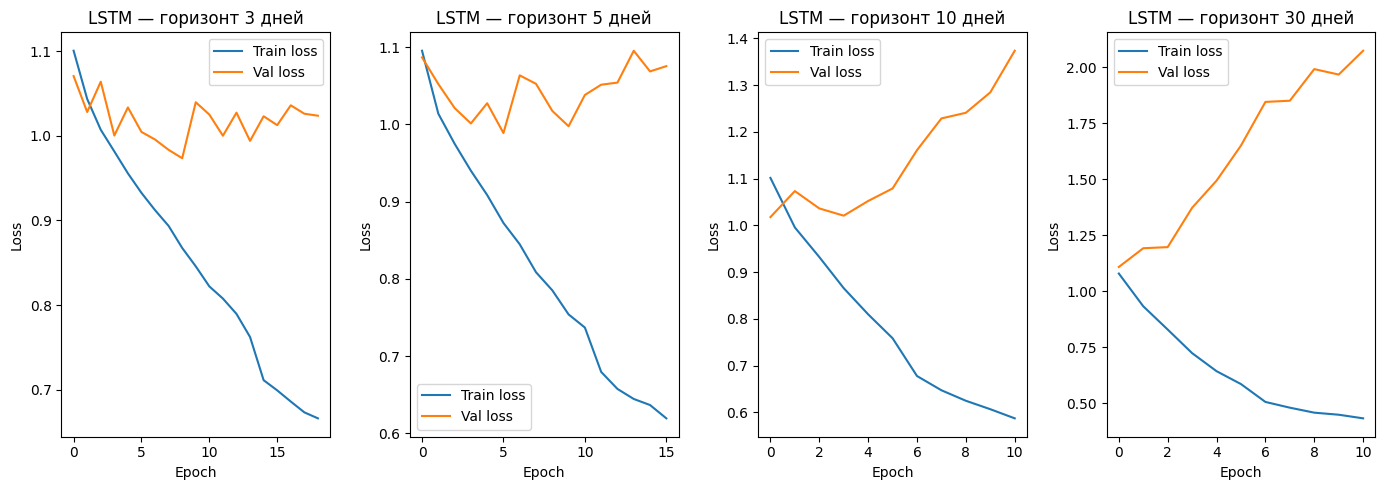

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for i, h in enumerate(HORIZONS):
    history = lstm_results[h]["history"]
    axes[i].plot(history.history["loss"], label="Train loss")
    axes[i].plot(history.history["val_loss"], label="Val loss")
    axes[i].set_title(f"LSTM — горизонт {h} дней")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()

plt.tight_layout()
plt.savefig("../model/lstm_training.png", dpi=150)
plt.show()

In [27]:
# LightGBM результаты с макро
lgbm_results = {5: 0.3974, 10: 0.3980, 3: 0.374, 30:0.351}

print("Сравнение LSTM vs LightGBM (с макропризнаками):")
print(f"\n{'Горизонт':<12} {'LightGBM':<12} {'LSTM':<12} {'Победитель'}")
print("-" * 45)

for h in HORIZONS:
    lgbm = lgbm_results[h]
    lstm = lstm_results[h]["f1"]
    winner = "LSTM" if lstm > lgbm else "LightGBM"
    print(f"{h} дней{'':<6} {lgbm:<12} {lstm:<12} {winner}")

Сравнение LSTM vs LightGBM (с макропризнаками):

Горизонт     LightGBM     LSTM         Победитель
---------------------------------------------
3 дней       0.374        0.3149       LightGBM
5 дней       0.3974       0.3394       LightGBM
10 дней       0.398        0.376        LightGBM
30 дней       0.351        0.3775       LSTM


In [28]:
import os
os.makedirs("../model", exist_ok=True)

for h in HORIZONS:
    path = f"../model/lstm_model_{h}d.keras"
    lstm_results[h]["model"].save(path)
    print(f"Сохранено: {path}")

print("Готово!")


Сохранено: ../model/lstm_model_3d.keras
Сохранено: ../model/lstm_model_5d.keras
Сохранено: ../model/lstm_model_10d.keras
Сохранено: ../model/lstm_model_30d.keras
Готово!
